# Lecture 4 — Model Answer
## Scatter & Bubble: Gapminder

---


In [37]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Gapminder 2007 — GDP, Life Expectancy, Population by Country

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())


Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB


In [5]:
df['year'].value_counts()

year
1952    142
1957    142
1962    142
1967    142
1972    142
1977    142
1982    142
1987    142
1992    142
1997    142
2002    142
2007    142
Name: count, dtype: int64

## Task 1 — Model Answer


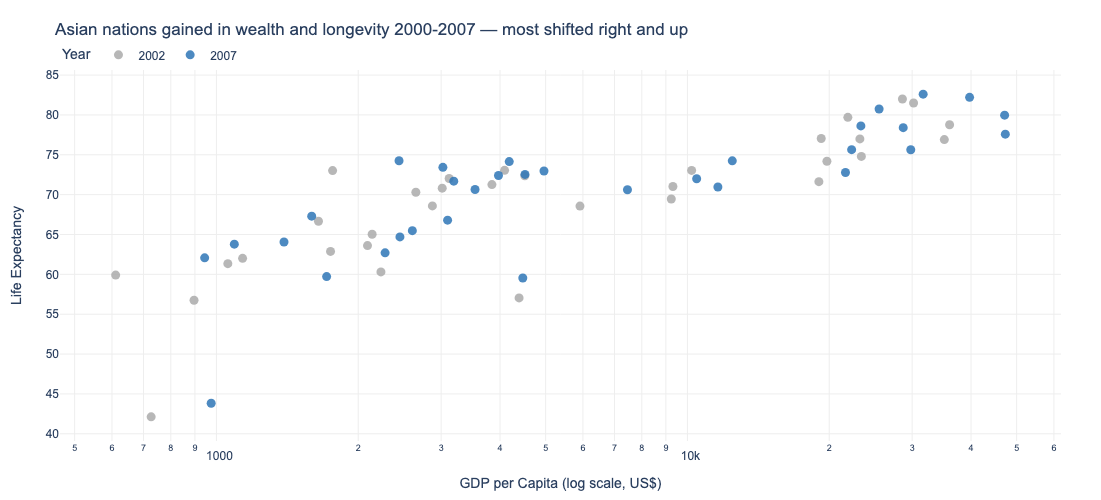

In [34]:
# prep data

asia = df[(df['continent'] == 'Asia') & (df['year'].isin([2002, 2007]))]
asia.loc[:, 'year'] = asia.loc[:, 'year'].astype(str)

# ── Step 1: Plotly Express base chart ─────────────────────────────────────────
fig = px.scatter(
    data_frame=asia,
    x='gdpPercap',
    y='lifeExp',
    color='year',                         
    hover_name='country',
    hover_data={'year': False},
    title='Asian nations gained in wealth and longevity 2000-2007 — most shifted right and up',
    labels={'gdpPercap': 'GDP per Capita (log scale, US$)', 'lifeExp': 'Life Expectancy'},
    color_discrete_map={'2002': '#AAAAAA', '2007': '#2E75B6'},  
    log_x=True,
    height=500
)

# ── Step 2: Graph Objects customisation ───────────────────────────────────────
fig.update_traces(
    marker=dict(size=9, opacity=0.85)
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    legend=dict(title='Year', orientation='h', y=1.08),
    margin=dict(l=60, r=40, t=70, b=40),
)

fig.update_xaxes(gridcolor='#EEEEEE')
fig.update_yaxes(gridcolor='#EEEEEE')

fig.show()

## Task 2 — Model Answer


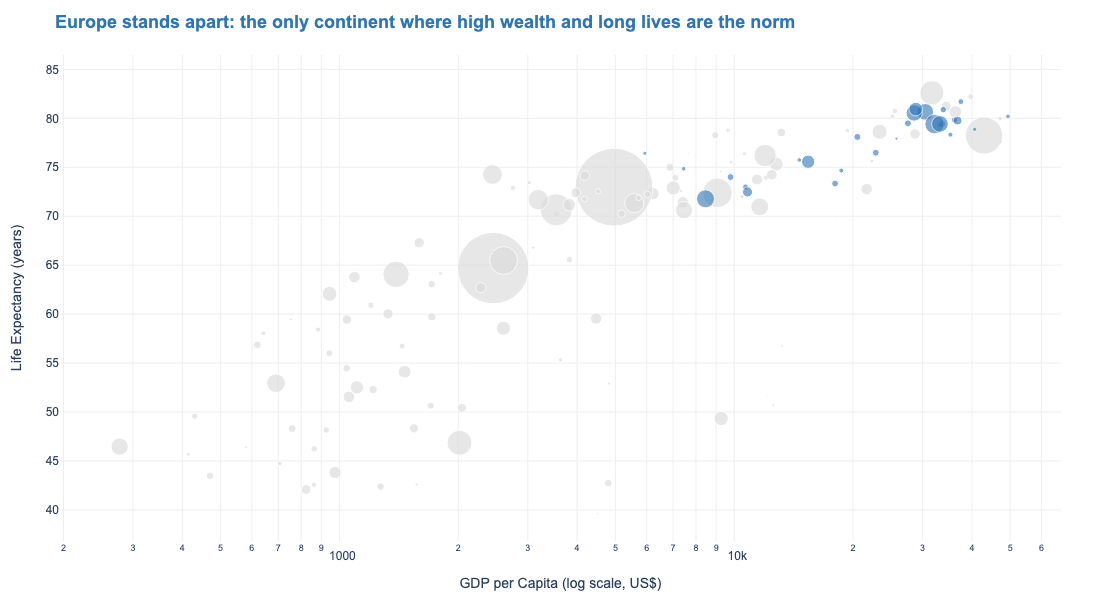

In [55]:

# prep data
highlight = 'Europe'
df07 = df.loc[df['year'] == 2007].copy()
df07['color_role'] = df07['continent'].apply(lambda c: 'Europe' if c == highlight else 'Other')


# ── Step 1: Plotly Express base chart ─────────────────────────────────────────
fig = px.scatter(
    data_frame=df07,
    x='gdpPercap',
    y='lifeExp',
    size='pop',                    # bubble size encodes population
    color='color_role',                    # 'Europe' → blue, 'Other' → grey
    hover_name='country',
    title='<b>Europe stands apart: the only continent where high wealth and long lives are the norm</b>',
    labels={'gdpPercap': 'GDP per Capita (log scale, US$)', 'lifeExp': 'Life Expectancy (years)', 'pop': 'Population'},
    color_discrete_map={'Europe': '#2E75B6', 'Other': '#DDDDDD'},
    category_orders={'color_role': ['Other', 'Europe']},  # Other drawn first, Europe on top
    log_x=True,
    size_max=55,
    height=600, width=1100
)

# ── Step 2: Graph Objects customisation ───────────────────────────────────────

fig.update_traces(
    selector=dict(name='Europe'),
    marker=dict(opacity=0.6))

fig.update_layout(
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    margin=dict(l=60, r=40, t=55, b=40),
    title=dict(font=dict(color='#2E75B6', size=18)))

fig.update_xaxes(gridcolor='#EEEEEE')
fig.update_yaxes(gridcolor='#EEEEEE')

fig.show()